In [1]:
import sys
sys.path.append('D:\\InProbation\\Metocean\\scripts')
import metocean_metadata
import visualizing
import wind_data_processing
import data_loading
import common_processing

from metocean_metadata import *
from visualizing import *
from data_loading import *
from common_processing import *
from wind_data_processing import *

import pandas as pd
import cartopy
import pyextremes
from pyextremes.plotting import plot_extremes
import scipy.stats as sstats

c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:

dir_extreme_anal = dir_analysis + 'Extreme conditions\\Wind\\'
fname_hist_tp = dir_tp_selected + '\\typhoon_selected.xlsx'
# typhoon_selected = sel_typhoon_affected(typhoon_ref_point, typhoon_search_cri_dhi, 
#                                         dir_btd, '', dir_tp_jra3q, fname_save=fname_hist_tp)

tp_sel_wink = pd.read_excel(fname_hist_tp, sheet_name='WINK')
tp_sel_jma = pd.read_excel(fname_hist_tp, sheet_name='JMA')
btd_typhoons = read_jma_btd(dir_btd)


In [3]:
conds = ['non_typhoon', 'typhoon', 'combined']

cond = 'non_typhoon'

hub_height = 100 # 
turbine_locs = pd.read_csv(dir_turbine_info + 'turbine_locs.txt', index_col=False)
delivery_locs = dict({'loc1':[33.75, 126.75]}) # chosen of delivery location for wind and other parameter also

era5_type = 'korea_0.25' # korea_0.25, windfield_0.05
typhoon_sel = pd.read_excel(dir_tp_selected+'typhoon_selected_combine.xlsx')

In [4]:
#%% LOAD ERA5 DATA
era5_all_year = pd.DataFrame()
for year in range(1979, 2026):
    [era5_u, era5_v]= load_era5_wind_data(dir_era5_wind + era5_type +'\\', 'wind_10m', year=year)
    era5_ws, era5_wd = compute_ws_wd_from_u_v(era5_u.sel(latitude=delivery_locs['loc1'][0], longitude=delivery_locs['loc1'][1], method='nearest').u10.values, 
                                                era5_v.sel(latitude=delivery_locs['loc1'][0], longitude=delivery_locs['loc1'][1], method='nearest').v10.values)
    era5_ws = pd.DataFrame(era5_ws, columns=['WS (m/s)'])
    era5_wd = pd.DataFrame(era5_wd, columns=['WD (deg)'])

    try:
        era5_ws['Time'] = era5_u.valid_time.values
        era5_wd['Time'] = era5_u.valid_time.values
    except:
        era5_ws['Time'] = era5_u.time.values
        era5_wd['Time'] = era5_u.time.values
    era5_ws = era5_ws.iloc[:, [1,0]]
    era5_ws['Time'] = pd.DatetimeIndex(era5_ws['Time']) + timedelta(hours=9)
    era5_wd['Time'] = pd.DatetimeIndex(era5_wd['Time']) + timedelta(hours=9)
    era5_yearly = pd.merge(era5_ws, era5_wd, how='right', on='Time')
    era5_all_year = pd.concat([era5_all_year, era5_yearly])
    

# Non typhoon conditions

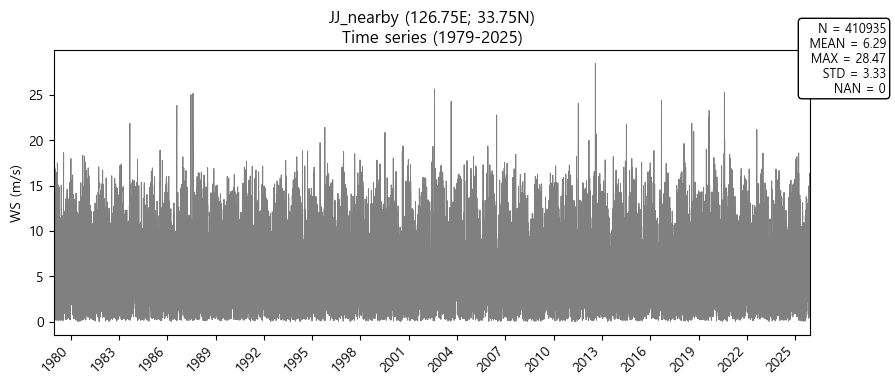

In [5]:
cond = 'non_typhoon' #  non-typhoon condition

# remove period when typhoons affecting study site
dir_working = dir_extreme_anal + cond + '\\'
era5_non_tp = extract_era5_non_typhoon_wind(typhoon_sel, era5_all_year)
era5_non_tp = era5_non_tp.dropna()

# Time series and rose plot
fig_title = f'JJ_nearby ({delivery_locs["loc1"][1]}E; {delivery_locs["loc1"][0]}N){nl}Time series (1979-2025)'
plot_time_series_1var(data=era5_non_tp, x_label='Time', y_label='WS (m/s)', fig_size=[9,4],face_color ='#808080',
                        fig_title=fig_title, fname_save=dir_working+'JJ_nearby_timeseries.png', long_term=True)

fig_title= f'JJ_nearby ({delivery_locs["loc1"][1]}E; {delivery_locs["loc1"][0]}N)<br>Rose plot (1979-2025)'
lg_title = f'ERA5<br>N={len(era5_non_tp)}<br>WS<sub>10m</sub>[m/s]<br>WD[{chr(176)}N-from]'
rose_plot(era5_non_tp, lg_title=lg_title, speed_name='WS (m/s)', dir_name='WD (deg)', 
            fig_title=fig_title, fname_save=dir_working+'JJ_nearby_rose_plot.png')


# do extreme analysis, fixed with AM and Gumbel for now. May 12
era5_non_tp = era5_non_tp.set_index('Time')

ex_type = 'high'
block_size = '365.2425D'
ex_method = 'BM'
rp_size = '365.2425D'

# omni directional analysis

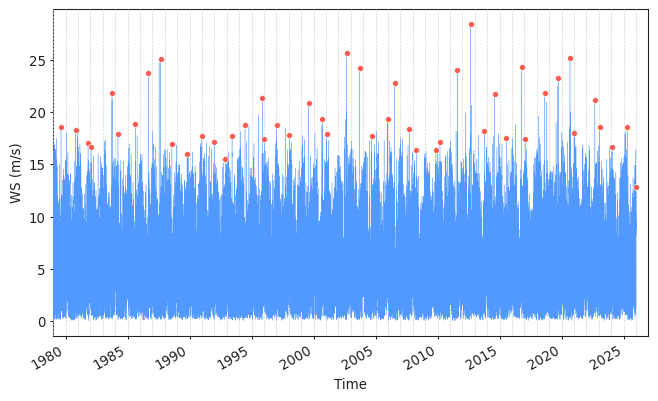

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                      WS (m/s)      Size:                             410,935
Start:                       January 1979      End:                         January 2026
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 48      Extraction method:                     BM
Type:                                high      Block size:             365 days 05:49:12
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

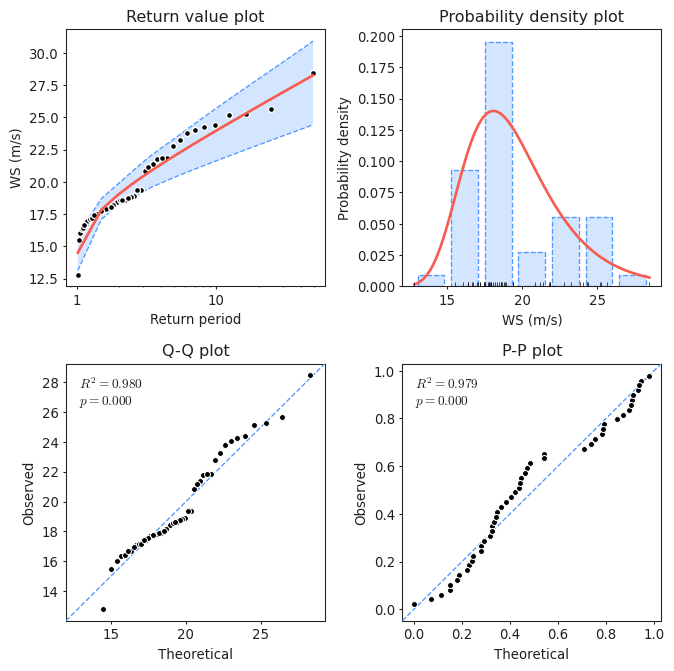

In [31]:
from pyextremes import EVA 
nontp_model = EVA(era5_non_tp['WS (m/s)'])
nontp_model.get_extremes(method="BM", block_size=pd.to_timedelta("365.2425D") * 1)
# nontp_model.get_extremes(method="POT", r='36h')
nontp_model.plot_extremes()
plt.margins(x=0)
plt.savefig(dir_working+'omni_AM.png')
plt.show()

# nontp_model.fit_model(model='MLE', distribution='gumbel_r')
nontp_model.fit_model()
print(nontp_model)
summary = nontp_model.get_summary(
    return_period=[1.1, 10, 50, 100],
    alpha=0.95,
    n_samples=1000,
)
print(summary)
nontp_model.plot_diagnostic(alpha=0.95)
plt.savefig(dir_working+'omni_AM_model_diagnostic.png')
plt.show()



In [24]:
return_period = [1.001, 10, 50, 100]
return_values = nontp_model.get_return_value(return_period, alpha=0.95)
return_values

(array([17.84382249, 22.94020191, 26.13239844, 27.4948251 ]),
 array([17.43797425, 21.63287406, 24.16829698, 25.23208507]),
 array([18.13763894, 23.78613463, 27.37029428, 28.92564053]))

In [25]:
from pyextremes import get_extremes, get_return_periods

return_periods = get_return_periods(
    ts=era5_non_tp['WS (m/s)'],
    extremes=nontp_model.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2425D",
    return_period_size="365.2425D",
    plotting_position="weibull",
)
return_periods.sort_values("return period", ascending=False).head()

,WS (m/s),exceedance probability,return period
Time,,,
2012-08-28 04:00:00,28.467313,0.010417,96.0
2002-08-31 09:00:00,25.647423,0.020833,48.0
2020-09-02 19:00:00,25.237564,0.031250,32.0
1987-08-30 23:00:00,25.160416,0.041667,24.0
2016-10-05 07:00:00,24.376333,0.052083,19.2
